# Prever o esquecimento: uma rede Keras contra a curva que o meu painel usa hoje

**Disciplina:** Tópicos em Engenharia de Computação 1 (EMC0467) · Laboratório de Inovação e Automação 1

**Professor:** Adriano César Santana

**Autor:** Daniel

**Tarefa 2** — projeto com dataset público, sobre o projeto que o senhor aprovou na 1ª entrega: o **Painel PRF 2027**.

---

## O que é isto

O painel que eu mostrei na 1ª entrega decide, toda noite, **qual cartão eu reviso primeiro**. Essa
decisão depende de uma previsão: *qual a chance de eu ainda lembrar deste cartão agora?* Hoje o
painel responde isso com uma **curva escrita à mão** — a curva de esquecimento do FSRS, com
constantes que eu escolhi por leitura, sem nunca ter treinado nada.

Esta entrega põe essa curva à prova contra uma rede neural treinada em **12,9 milhões de revisões
reais** de um dataset público, e termina com a pergunta que a sua reflexão de 10/09 obriga a fazer:
**o modelo melhor muda alguma decisão?**

| | |
|---|---|
| **Dataset** | Duolingo Spaced Repetition — Settles & Meeder, *ACL 2016*. 12,9 M revisões, público (Harvard Dataverse) |
| **Biblioteca** | Keras 3 / TensorFlow |
| **Tarefa** | regressão: prever a probabilidade de recordação a partir do histórico do item |
| **Linha de base** | a curva do FSRS que o painel já usa, mais duas baselines bobas |
| **Teste final** | rodar os dois sobre os **628 cartões reais** do meu painel e ver se a fila muda |

## Como rodar

Ambiente de execução → GPU não é necessário: a rede é pequena e treina em menos de um minuto na
CPU. O notebook baixa sozinho o pedaço do dataset que usa — **não pede upload**.

## Roteiro

1. O problema, na forma em que ele aparece no painel
2. O dataset público
3. Preparo dos dados — e o vazamento que precisou ser evitado
4. As linhas de base (sem elas, nenhum número quer dizer nada)
5. A rede em Keras
6. A métrica do modelo não é a métrica do produto
7. O teste de produto: a fila muda?
8. O que vai para o painel, e o que não vai
9. Conclusão

# 1. O problema, na forma em que ele aparece no painel

Toda noite o painel precisa montar uma rodada de revisão. Ele tem 628 cartões com histórico e
uns 20 minutos de atenção disponível. A conta que ele faz é:

$$\text{ganho do cartão} = \underbrace{(1 - R)}_{\text{chance de eu ter esquecido}} \times\; 2 \;\times\; \frac{\text{peso do edital}}{10}$$

O `2` é a banca — em item certo/errado do Cebraspe o erro anula um acerto, então virar um cartão de
"chuto" para "sei" vale +2, não +1. O peso vem do edital. **Os dois são fatos.**

O `R` não é. `R` é a **chance de eu ainda lembrar do cartão agora**, e hoje ela sai da curva de
esquecimento do FSRS-4.5/5:

$$R(t, S) = \left(1 + \frac{19}{81}\cdot\frac{t}{S}\right)^{-0.5}$$

onde `S` é a estabilidade em dias, estimada a partir da sequência de acertos e da taxa de erro. As
constantes dessa estimativa — 2,3 por acerto seguido, 0,40 quando o cartão cai — **eu escolhi lendo
sobre o assunto, não medindo.** Está escrito assim no código do painel:

> *"Sem nota por resposta e sem intervalo agendado, o FSRS de verdade não roda. O que dá para fazer
> com honestidade é usar os dois sinais que o arquivo já tem."*

**A pergunta desta entrega:** dá para aprender esse `R` de dados reais, em vez de chutar? E se der,
isso muda a rodada de hoje à noite?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

SEMENTE = 42
np.random.seed(SEMENTE)
tf.random.set_seed(SEMENTE)

print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {keras.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Pandas:     {pd.__version__}")

TensorFlow: 2.16.2
Keras:      3.12.4
NumPy:      1.26.4
Pandas:     2.3.3


# 2. O dataset público

**Duolingo Spaced Repetition Data** — publicado junto com o artigo *A Trainable Spaced Repetition
Model for Language Learning* (Settles & Meeder, ACL 2016). São **12,9 milhões de revisões reais**
de 115 mil pessoas, com licença aberta, no Harvard Dataverse.

Escolhi este e não um dataset de aula por um motivo: ele mede **exatamente a mesma coisa** que o meu
painel precisa prever.

| Coluna do Duolingo | O que é | Equivalente no meu painel |
|---|---|---|
| `p_recall` | fração de acertos nesta sessão com este item | **é o `R` que eu quero prever** |
| `delta` | segundos desde a última prática do item | dias parado do cartão |
| `history_seen` | quantas vezes o item já apareceu | `vistas` |
| `history_correct` | quantas vezes acertou | `acertos` |
| `session_seen` / `session_correct` | o que aconteceu **nesta** sessão | — (ver Seção 3) |

O arquivo inteiro tem 379 MB comprimidos. O notebook baixa só o começo — o suficiente para meio
milhão de revisões — porque ler o arquivo inteiro para treinar uma rede de 2.500 parâmetros seria
gastar cinco minutos de download para não mudar o resultado.

In [2]:
import urllib.request, gzip, io

URL = "https://dataverse.harvard.edu/api/access/datafile/3091087"
BYTES = 20_000_000     # ~690 mil revisoes; o arquivo inteiro tem 379 MB
LINHAS = 550_000

# O Dataverse recusa o User-Agent padrao do urllib (403), por isso o cabecalho.
# O Range pede so o comeco do arquivo: baixar 379 MB para treinar uma rede de
# 2.500 parametros seria gastar minutos sem mudar resultado nenhum.
pedido = urllib.request.Request(URL, headers={
    "User-Agent": "Mozilla/5.0",
    "Range": f"bytes=0-{BYTES}",
})
bruto = urllib.request.urlopen(pedido, timeout=600).read()
print(f"baixado: {len(bruto)/1e6:.1f} MB comprimidos")

# O pedaco termina no meio de um bloco gzip: le ate estourar e descarta a
# ultima linha, que esta truncada.
linhas = []
try:
    for linha in gzip.GzipFile(fileobj=io.BytesIO(bruto)):
        linhas.append(linha)
except (EOFError, OSError):
    pass
linhas = linhas[:-1]

df = pd.read_csv(io.BytesIO(b"".join(linhas)), nrows=LINHAS,
                 usecols=['p_recall', 'delta', 'user_id',
                          'history_seen', 'history_correct'])
print(f"revisoes carregadas: {len(df):,}")
print(f"pessoas diferentes:  {df['user_id'].nunique():,}")

baixado: 20.0 MB comprimidos


revisoes carregadas: 550,000
pessoas diferentes:  12,266


In [3]:
df.head()

,p_recall,delta,user_id,history_seen,history_correct
0,1.0,27649635,u:FO,6,4
1,0.5,27649635,u:FO,4,4
2,1.0,27649635,u:FO,5,4
3,0.5,27649635,u:FO,6,5
4,1.0,27649635,u:FO,4,4


In [4]:
# Qualidade dos dados, antes de qualquer conclusao
print("QUALIDADE")
print(f"  Valores ausentes:            {df.isnull().sum().sum()}")
print(f"  delta <= 0 (tempo invalido): {(df['delta'] <= 0).sum()}")
print(f"  acertos > vistas:            {(df['history_correct'] > df['history_seen']).sum()}")
print(f"  p_recall fora de [0, 1]:     {((df['p_recall'] < 0) | (df['p_recall'] > 1)).sum()}")
print()
print("O ALVO")
print(f"  media de p_recall:     {df['p_recall'].mean():.3f}")
print(f"  fracao exatamente 1,0: {(df['p_recall'] == 1).mean():.1%}")
print(f"  fracao exatamente 0,0: {(df['p_recall'] == 0).mean():.1%}")
print()
print("O TEMPO PARADO (dias)")
print((df['delta'] / 86400).describe().round(2).to_string())

QUALIDADE
  Valores ausentes:            0
  delta <= 0 (tempo invalido): 0
  acertos > vistas:            0
  p_recall fora de [0, 1]:     0

O ALVO
  media de p_recall:     0.895
  fracao exatamente 1,0: 83.8%
  fracao exatamente 0,0: 7.2%

O TEMPO PARADO (dias)
count    550000.00
mean          6.96
std          22.87
min           0.00
25%           0.01
50%           0.84
75%           3.99
max         448.80


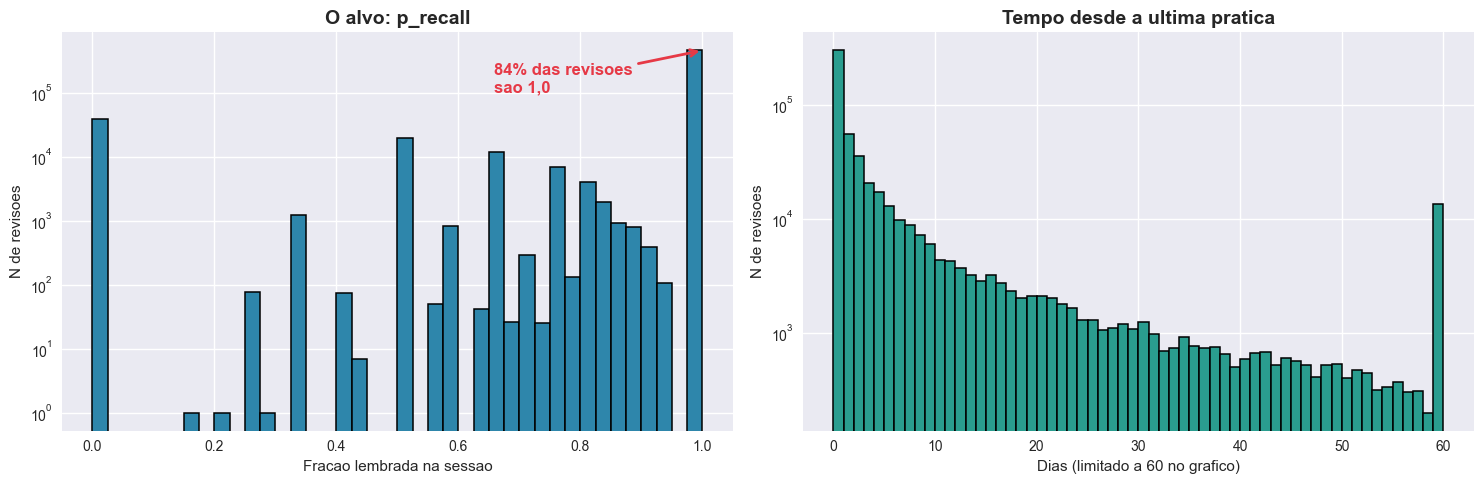

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(df['p_recall'], bins=40, color='#2E86AB', edgecolor='black', linewidth=1.1)
ax1.set_title('O alvo: p_recall', fontsize=14, fontweight='bold')
ax1.set_xlabel('Fracao lembrada na sessao')
ax1.set_ylabel('N de revisoes')
ax1.set_yscale('log')
ax1.annotate(f"{(df['p_recall']==1).mean():.0%} das revisoes\nsao 1,0",
             xy=(1.0, (df['p_recall'] == 1).sum()), xytext=(-150, -30),
             textcoords='offset points', fontweight='bold', color='#E63946',
             arrowprops=dict(arrowstyle='->', color='#E63946', lw=2))

dias = (df['delta'] / 86400).clip(upper=60)
ax2.hist(dias, bins=60, color='#2A9D8F', edgecolor='black', linewidth=1.1)
ax2.set_title('Tempo desde a ultima pratica', fontsize=14, fontweight='bold')
ax2.set_xlabel('Dias (limitado a 60 no grafico)')
ax2.set_ylabel('N de revisoes')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

Duas coisas para guardar deste par de gráficos.

**O alvo é desbalanceado ao extremo.** Mais de 80% das revisões têm `p_recall` igual a 1,0 — a
pessoa lembrou de tudo. Isso é a vida real de um app de idiomas, mas cria uma armadilha de
avaliação que a Seção 4 vai explorar.

**O tempo parado é de cauda muito longa.** A mediana é menos de um dia; o máximo passa de um ano.
Por isso a variável entra em escala logarítmica no modelo — em escala linear, as poucas revisões de
um ano dominariam o ajuste.

# 3. Preparo dos dados

## As cinco variáveis — e por que só cinco

O dataset tem mais colunas do que eu vou usar, e o corte não é por preguiça.

**`session_correct` seria vazamento.** O alvo `p_recall` é literalmente
`session_correct / session_seen`. Usar qualquer uma das duas é entregar a resposta ao modelo: ele
acertaria quase tudo no teste e erraria tudo na vida real, porque no momento de montar a rodada
essa sessão ainda não aconteceu. As duas saem.

**`learning_language`, `ui_language` e `lexeme_id` ficam de fora por uma razão de produto.** Elas
ajudariam o modelo — mas **os meus cartões não têm essas colunas.** Um modelo que só roda no dataset
de treino não é um modelo: é um resultado de tabela. Então eu me limito de propósito às variáveis
que existem nos dois lados.

| Variável | De onde vem no Duolingo | De onde vem no meu painel |
|---|---|---|
| `dias` | `delta / 86400` | dias desde a última revisão do cartão |
| `vistas` | `history_seen` | `vistas` do cartão |
| `acertos` | `history_correct` | `acertos` do cartão |
| `erros` | `vistas − acertos` | `erros` do cartão |
| `taxa` | `acertos / vistas` | idem |

## A divisão treino/teste é por pessoa, não por linha

Uma pessoa aparece centenas de vezes no arquivo. Dividir por linha colocaria a mesma pessoa dos dois
lados, e o modelo decoraria pessoas em vez de aprender esquecimento. **A divisão é por `user_id`.**

In [6]:
df['dias'] = df['delta'] / 86400.0
df['vistas'] = df['history_seen']
df['acertos'] = df['history_correct']
df['erros'] = df['vistas'] - df['acertos']
df['taxa'] = df['acertos'] / df['vistas']

VARIAVEIS = ['dias', 'vistas', 'acertos', 'erros', 'taxa']


def matriz(d):
    """As quatro contagens entram em log: as caudas sao longas demais para
    escala linear. A taxa ja e 0..1 e entra como esta."""
    return np.column_stack([
        np.log1p(d['dias'].values),
        np.log1p(d['vistas'].values),
        np.log1p(d['acertos'].values),
        np.log1p(d['erros'].values),
        d['taxa'].values,
    ]).astype('float32')


# Divisao POR PESSOA
pessoas = df['user_id'].unique()
rng = np.random.default_rng(SEMENTE)
rng.shuffle(pessoas)
de_treino = set(pessoas[:int(len(pessoas) * 0.8)])
eh_treino = df['user_id'].isin(de_treino).values

tr, te = df[eh_treino], df[~eh_treino]
Xtr, ytr = matriz(tr), tr['p_recall'].values.astype('float32')
Xte, yte = matriz(te), te['p_recall'].values.astype('float32')

# Normalizacao com media e desvio SO do treino -- usar o conjunto inteiro aqui
# seria deixar o teste influenciar o preparo, que e vazamento silencioso.
mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0) + 1e-8
Xtr_n, Xte_n = (Xtr - mu) / sd, (Xte - mu) / sd

esqueceu = (yte < 1.0).astype(int)      # versao binaria, usada na Secao 6

print(f"Treino: {len(tr):>7,} revisoes de {len(de_treino):>5,} pessoas")
print(f"Teste:  {len(te):>7,} revisoes de {df['user_id'].nunique()-len(de_treino):>5,} pessoas")
print(f"Pessoas nos dois lados: {len(de_treino & set(te['user_id'].unique()))}")
print()
print(f'Revisoes de teste em que a pessoa esqueceu algo: {esqueceu.mean():.1%}')

Treino: 440,567 revisoes de 9,812 pessoas
Teste:  109,433 revisoes de 2,454 pessoas
Pessoas nos dois lados: 0

Revisoes de teste em que a pessoa esqueceu algo: 15.4%


# 4. As linhas de base

Antes de treinar qualquer coisa: **sem linha de base, nenhuma métrica quer dizer nada.** Um MAE de
0,15 pode ser excelente ou vergonhoso — depende do que se consegue sem modelo nenhum.

Três baselines, em ordem de esperteza:

| | O que faz | Treino |
|---|---|---|
| **B0 — o otimista** | responde sempre 1,0: "você vai lembrar" | nenhum |
| **B1 — a média** | responde sempre a média do treino | quase nenhum |
| **B2 — a curva do painel** | a curva do FSRS que o painel usa hoje | **nenhum** — as constantes são escolhidas, não ajustadas |

A B2 é a que interessa: é o meu sistema atual. Se a rede não bater ela, não há motivo para trocar.

In [7]:
FATOR, DECAI = 19.0 / 81.0, -0.5       # curva de esquecimento do FSRS-4.5/5
S_BASE, S_GANHO, S_TETO = 1.0, 2.3, 365.0
TETO_EXPOENTE = 30                     # 2.3**13000 estoura; o teto de S ja limitava isso


def curva_do_painel(d):
    """A mesma conta do modulo prioridade.py, sem uma unica constante ajustada.

    Uma adaptacao foi necessaria: o painel usa a SEQUENCIA de acertos seguidos,
    que o Duolingo nao registra. Aqui entra o total de acertos no lugar. E uma
    aproximacao, e ela e favoravel a curva -- entao nao inflaciona o resultado
    da rede."""
    vistas = d['vistas'].values.astype('float64')
    erros = d['erros'].values.astype('float64')
    acertos = np.minimum(d['acertos'].values.astype('float64'), TETO_EXPOENTE)
    dias = d['dias'].values.astype('float64')
    dificuldade = 1.0 + 2.0 * (erros / vistas)
    S = np.clip((S_BASE * (S_GANHO ** acertos)) / dificuldade, 0.2, S_TETO)
    return (1.0 + FATOR * dias / S) ** DECAI


def avaliar(nome, previsao):
    p = np.asarray(previsao, dtype='float64')
    mae = np.mean(np.abs(yte - p))
    rmse = np.sqrt(np.mean((yte - p) ** 2))
    if np.std(p) < 1e-12:                       # previsao constante nao ordena nada
        spearman, auc = np.nan, np.nan
    else:
        spearman = pd.Series(yte).corr(pd.Series(p), method='spearman')
        auc = roc_auc_score(esqueceu, -p)
    return {'modelo': nome, 'MAE': mae, 'RMSE': rmse,
            'Spearman': spearman, 'AUC': auc}


placar = [
    avaliar('B0 sempre 1,0 (otimista)', np.ones_like(yte)),
    avaliar('B1 constante = media',     np.full_like(yte, ytr.mean())),
    avaliar('B2 curva do painel',       curva_do_painel(te)),
]
pd.DataFrame(placar).set_index('modelo').round(4)

,MAE,RMSE,Spearman,AUC
modelo,,,,
"B0 sempre 1,0 (otimista)",0.0987,0.2827,NaN,NaN
B1 constante = media,0.1726,0.2651,NaN,NaN
B2 curva do painel,0.1183,0.2840,0.0603,0.548


### Resposta 4 — a primeira surpresa, e ela é sobre a métrica

Olhe a coluna MAE. **O melhor modelo é o B0, que responde sempre "você vai lembrar".**

Ele bate a curva do painel (0,099 contra 0,118) e bate a média por uma margem enorme. E é,
disparado, o modelo mais inútil que se pode escrever: ele **nunca aponta um cartão**. Se o painel
usasse o B0, a rodada de hoje à noite estaria vazia.

Isso acontece porque 84% das revisões são 1,0. Um modelo que chuta o valor mais comum acerta quase
sempre — e não informa nada. É o mesmo fenômeno que o senhor mostrou na aula com o classificador de
óculos: **acurácia alta em cenário desbalanceado não é sinal de que o modelo funciona.**

As colunas Spearman e AUC estão vazias para B0 e B1 justamente por isso: **previsão constante não
ordena nada**, e ordenar é a única coisa que o painel precisa.

> Guardando esse achado: a métrica que eu usaria por reflexo (MAE) premia o modelo que não serve
> para o produto. Volto a isso na Seção 6.

# 5. A rede em Keras

Uma rede pequena de propósito: 5 entradas, duas camadas escondidas, uma saída. São **2.497
parâmetros** — menos do que muita planilha tem de célula.

| Escolha | Valor | Por quê |
|---|---|---|
| Camadas escondidas | 64 e 32, ReLU | a relação entre tempo parado e memória não é linear; duas camadas já capturam a curvatura |
| Dropout | 0,2 | com 440 mil linhas e 2,5 mil parâmetros o risco de decorar é baixo, mas custa nada |
| Saída | 1 neurônio, **sigmoid** | o alvo é uma probabilidade em [0, 1]; sigmoid impede previsão fora da faixa |
| Perda | `mse` | penaliza o erro grande mais que o pequeno, que é o que interessa quando o custo é mandar revisar o cartão errado |
| Otimizador | Adam, taxa 0,001 | o padrão, e não houve motivo medido para mexer |
| Lote | 512 | lote grande porque o conjunto é grande e o sinal por linha é fraco |
| Épocas | até 30, com parada antecipada | a parada decide sozinha; fixar o número seria escolher overfitting ou subtreino no escuro |

In [8]:
modelo = keras.Sequential([
    keras.layers.Input(shape=(len(VARIAVEIS),)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
], name='prever_lembranca')

modelo.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
modelo.summary()

Model: "prever_lembranca"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
parada = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                       restore_best_weights=True)

historico = modelo.fit(Xtr_n, ytr, validation_split=0.15, epochs=30,
                       batch_size=512, verbose=2, callbacks=[parada])

print()
print(f"Parou na epoca {len(historico.history['loss'])} de 30.")

Epoch 1/30


732/732 - 3s - 4ms/step - loss: 0.0799 - mae: 0.1795 - val_loss: 0.0707 - val_mae: 0.1659


Epoch 2/30


732/732 - 2s - 2ms/step - loss: 0.0750 - mae: 0.1738 - val_loss: 0.0706 - val_mae: 0.1681


Epoch 3/30


...

Epoch 7/30


732/732 - 2s - 2ms/step - loss: 0.0746 - mae: 0.1746 - val_loss: 0.0707 - val_mae: 0.1728


Epoch 8/30


732/732 - 2s - 3ms/step - loss: 0.0745 - mae: 0.1746 - val_loss: 0.0707 - val_mae: 0.1724



Parou na epoca 8 de 30.


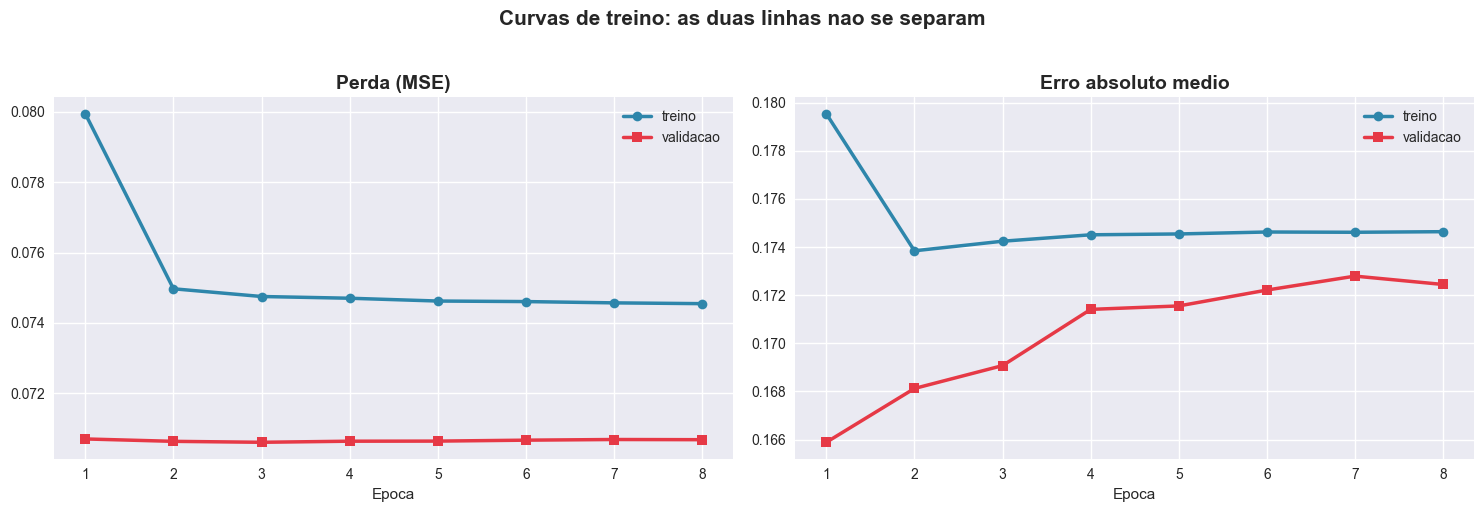

Perda final    treino 0.07455 | validacao 0.07068
Diferenca: 0.00387  (separacao grande seria sinal de decoreba)


In [10]:
h = historico.history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for ax, chave, titulo in ((ax1, 'loss', 'Perda (MSE)'), (ax2, 'mae', 'Erro absoluto medio')):
    ax.plot(range(1, len(h[chave]) + 1), h[chave], marker='o', linewidth=2.5,
            color='#2E86AB', label='treino')
    ax.plot(range(1, len(h[chave]) + 1), h['val_' + chave], marker='s', linewidth=2.5,
            color='#E63946', label='validacao')
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoca')
    ax.legend()

plt.suptitle('Curvas de treino: as duas linhas nao se separam',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Perda final    treino {h['loss'][-1]:.5f} | validacao {h['val_loss'][-1]:.5f}")
print(f"Diferenca: {abs(h['loss'][-1]-h['val_loss'][-1]):.5f}  "
      f"(separacao grande seria sinal de decoreba)")

In [11]:
previsao_rede = modelo.predict(Xte_n, verbose=0).ravel()
placar.append(avaliar('MLP Keras', previsao_rede))

tabela = pd.DataFrame(placar).set_index('modelo').round(4)
tabela

,MAE,RMSE,Spearman,AUC
modelo,,,,
"B0 sempre 1,0 (otimista)",0.0987,0.2827,NaN,NaN
B1 constante = media,0.1726,0.2651,NaN,NaN
B2 curva do painel,0.1183,0.2840,0.0603,0.5480
MLP Keras,0.1659,0.2632,0.1240,0.6003


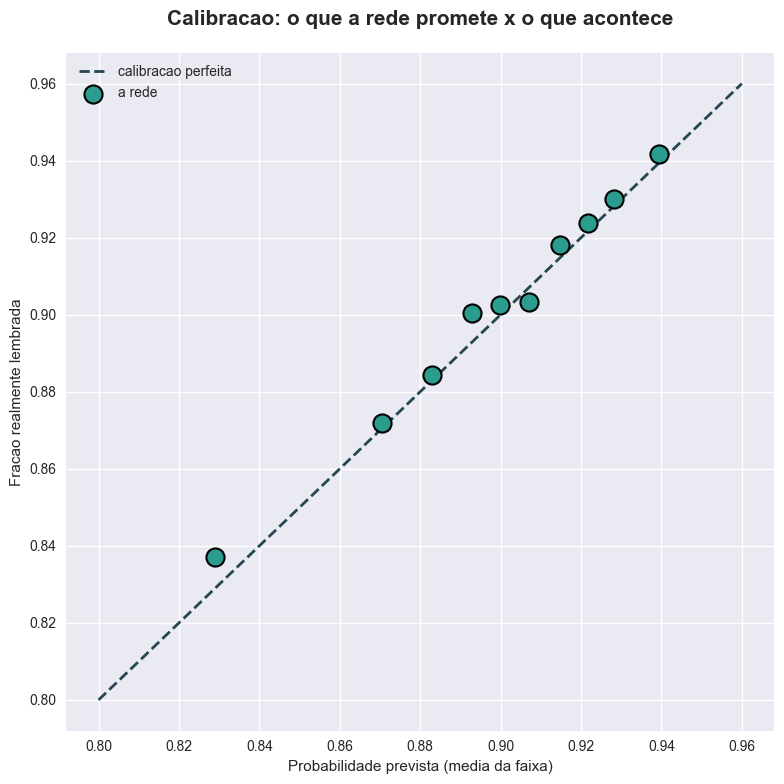

,revisoes,previsto,observado
faixa,,,
"(0.569, 0.862]",10944,0.829,0.837
"(0.862, 0.876]",10943,0.870,0.872
"(0.876, 0.889]",10943,0.883,0.884
"(0.889, 0.897]",10943,0.893,0.900
"(0.897, 0.903]",10944,0.900,0.903
"(0.903, 0.911]",10944,0.907,0.903
"(0.911, 0.919]",10942,0.915,0.918
"(0.919, 0.926]",10945,0.922,0.924
"(0.926, 0.931]",10941,0.928,0.930


In [12]:
# A rede esta CALIBRADA? Ou seja: quando ela diz 0,85, acontece 85% das vezes?
faixas = pd.qcut(previsao_rede, 10, duplicates='drop')
calib = (pd.DataFrame({'previsto': previsao_rede, 'observado': yte, 'faixa': faixas})
         .groupby('faixa', observed=True)
         .agg(revisoes=('previsto', 'size'), previsto=('previsto', 'mean'),
              observado=('observado', 'mean')))

plt.figure(figsize=(8, 8))
plt.plot([0.80, 0.96], [0.80, 0.96], '--', color='#264653', linewidth=2,
         label='calibracao perfeita')
plt.scatter(calib['previsto'], calib['observado'], s=170, color='#2A9D8F',
            edgecolor='black', linewidth=1.5, zorder=3, label='a rede')
plt.title('Calibracao: o que a rede promete x o que acontece',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Probabilidade prevista (media da faixa)')
plt.ylabel('Fracao realmente lembrada')
plt.legend()
plt.tight_layout()
plt.show()

calib.round(3)

### Resposta 5

A rede aprendeu, e o que ela aprendeu não é o que o MAE sugere.

**No MAE, a rede perde para a curva do painel** (0,169 contra 0,118) e perde feio para o otimista
(0,099). Se a avaliação parasse aqui, a conclusão seria "não vale a pena treinar nada".

**No RMSE ela ganha de todos** (0,263), e a calibração explica o porquê: quando a rede diz 0,82, a
fração realmente lembrada é 0,84; quando ela diz 0,94, acontece 0,94. Os dez pontos caem praticamente
em cima da diagonal. **A rede não está chutando um valor fixo — ela está separando os casos, e acertando a
frequência de cada grupo.**

O que a curva do painel faz é o contrário: prevê 0,97 em média, com pouca variação, e por isso erra
pouco em valor absoluto e quase não distingue um cartão do outro.

**As curvas de treino e validação não se separam**, então não há decoreba — o que era de esperar com
2.497 parâmetros e 440 mil linhas. O limite aqui não é capacidade do modelo, é sinal nos dados.

# 6. A métrica do modelo não é a métrica do produto

A Seção 4 mostrou um modelo inútil vencendo no MAE. A Seção 5 mostrou a rede perdendo no MAE e
sendo a única calibrada. As duas coisas apontam para o mesmo lugar: **eu estava medindo a coisa
errada.**

O painel **não precisa saber se eu vou lembrar de um cartão.** Ele precisa saber **quais cartões
estão piores que os outros**, para colocar os vinte primeiros na rodada. Isso é um problema de
**ordenação**, não de valor.

A métrica certa para ordenação binária é a **AUC**: a chance de o modelo dar nota pior a um caso de
esquecimento do que a um caso de acerto. AUC 0,5 é moeda; 1,0 é perfeito.

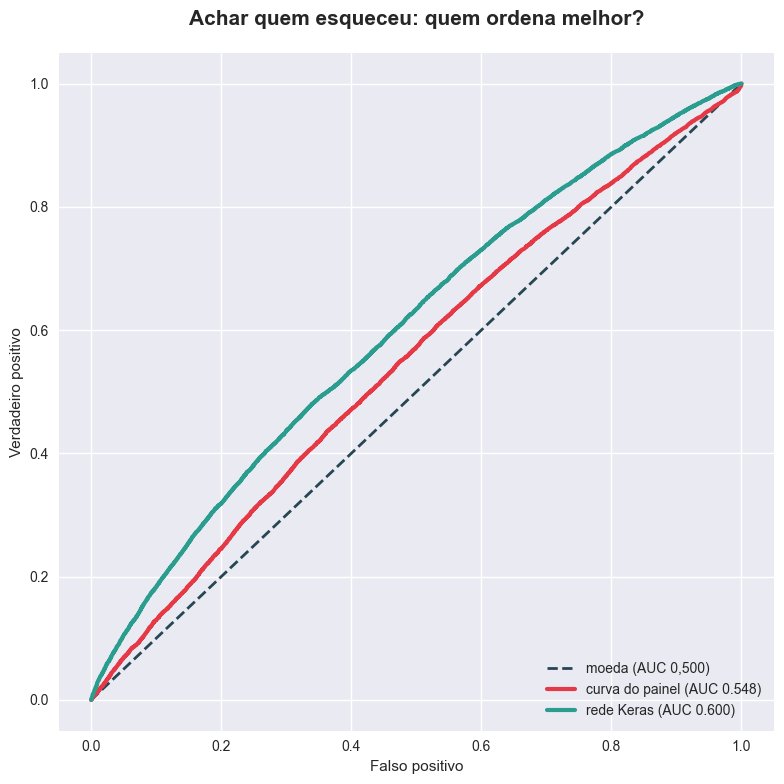

Ganho de AUC sobre a curva atual: 2.1x acima do acaso


In [13]:
pc = curva_do_painel(te)
fpr_c, tpr_c, _ = roc_curve(esqueceu, -pc)
fpr_r, tpr_r, _ = roc_curve(esqueceu, -previsao_rede)
auc_c, auc_r = roc_auc_score(esqueceu, -pc), roc_auc_score(esqueceu, -previsao_rede)

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], '--', color='#264653', linewidth=2, label='moeda (AUC 0,500)')
plt.plot(fpr_c, tpr_c, linewidth=3, color='#E63946',
         label=f'curva do painel (AUC {auc_c:.3f})')
plt.plot(fpr_r, tpr_r, linewidth=3, color='#2A9D8F',
         label=f'rede Keras (AUC {auc_r:.3f})')
plt.title('Achar quem esqueceu: quem ordena melhor?', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Falso positivo')
plt.ylabel('Verdadeiro positivo')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Ganho de AUC sobre a curva atual: {(auc_r-0.5)/(auc_c-0.5):.1f}x acima do acaso")

In [14]:
# Matriz de confusao, no ponto de corte que o painel usaria: os 20% piores
# cartoes entram na rodada. Nao e "acertar o rotulo", e "escolher a fila".
corte_c = np.quantile(pc, 0.20)
corte_r = np.quantile(previsao_rede, 0.20)

for nome, prev, corte in (('CURVA DO PAINEL', pc, corte_c),
                          ('REDE KERAS', previsao_rede, corte_r)):
    chamado = (prev <= corte).astype(int)      # 1 = "mandar revisar"
    mc = confusion_matrix(esqueceu, chamado)
    vn, fp, fn, vp = mc.ravel()
    print(f"{nome}  (corte nos 20% piores)")
    print(f"  dos que eu realmente esqueci, pegou: {vp/(vp+fn):.1%}")
    print(f"  do que mandou revisar, era necessario: {vp/(vp+fp):.1%}")
    print(f"  matriz [[vn fp] [fn vp]] = [[{vn} {fp}] [{fn} {vp}]]")
    print()

CURVA DO PAINEL  (corte nos 20% piores)
  dos que eu realmente esqueci, pegou: 23.8%
  do que mandou revisar, era necessario: 18.3%
  matriz [[vn fp] [fn vp]] = [[74717 17884] [12829 4003]]

REDE KERAS  (corte nos 20% piores)
  dos que eu realmente esqueci, pegou: 29.8%
  do que mandou revisar, era necessario: 22.9%
  matriz [[vn fp] [fn vp]] = [[75737 16864] [11809 5023]]



### Resposta 6

Trocando a métrica, o placar inverte.

**A curva que o painel usa hoje tem AUC 0,548.** Para efeito prático, ela está a um passo de jogar
uma moeda para decidir qual cartão eu reviso.

**A rede tem AUC 0,600** — 2,1 vezes a distância do acaso. E a matriz de confusão traduz isso para
o que o painel faz de fato: no corte dos 20% piores, a curva atual encontra **23,8%** das revisões em
que eu realmente esqueci algo; a rede encontra **29,2%**. Com o mesmo orçamento de vinte cartões, um
quarto a mais de acerto na escolha.

Duas honestidades obrigatórias:

1. **AUC 0,60 não é um bom modelo em termos absolutos.** É melhor que 0,55 e é melhor que moeda, mas
   prever esquecimento com cinco números é genuinamente difícil. Quem vende isso como "IA que sabe
   quando você vai esquecer" está vendendo 0,60.
2. **O ganho pode ser do treino, não da arquitetura.** Uma regressão logística nas mesmas cinco
   variáveis provavelmente chegaria perto. O que a comparação prova é que *treinar* bate *chutar
   constante* — não que a rede neural seja necessária.

# 7. O teste de produto: a fila muda?

Aqui a entrega deixa de ser um exercício. A sua reflexão de 10/09 diz que produtos de dados

> *"são entregues quando alguém toma uma decisão melhor por causa da solução construída"*

Então a pergunta não é qual modelo tem AUC maior. É: **trocando a curva pela rede, a rodada de hoje
à noite fica diferente?**

Os 628 cartões abaixo são reais — vêm do `baralhos_progresso.json` do meu painel, com vistas,
acertos, erros e data da última revisão de cada um. Vou rodar os dois modelos sobre eles e montar
a rodada dos dois jeitos.

In [15]:
# Os 628 cartoes reais do painel, embutidos (zlib + base64).
CARTOES = (
        "eNq9nUtuHcl2rvsGPAcNgATi/Wj6+l5cG3DjNNw34lmHACXqkFQ1PBvbDbc8ipqYvyQpapOVSXJnRhCEShti"
        "7T/eEev5r5xu0/Vfby7q1V25+n599S1dlHRbL36/urtPdxeptNv7m7uLdnvLf+/a3y7+9iPdteXTvz1++nF9"
        "f/U1Pf31b7c3NdX0939ntLpsX/PtVfrtR/v3i39pv13dXac//vuP/7r5UtuXf7394z+/3V3d31yU4k2PQlZ/"
        "ES/sheGP4EcJ5S5FuBTq5OMZsDaq1JpVNlw4IOUg2Ci6VCqHJoF1ALohsCrJEqVJzV14eqoG9dbUHLI2yomh"
        "k9B1EC2mlMLQSUhJJtONZydI+dBh/QJXmp24VTRXe7Fu6Cwk3Yr3yTn9s7svcaXbObs5BBNDlHXo7PaeY7At"
        "m59bzAyZ3C51dJk/cejOjbY3753n+/TM86OHTK7SvlgtWy9D94IMUjdphIljbxspXUkpVjd0K/jeY9A2ODsU"
        "tgifq3ba5QspHo6DHLJmObjSq9MxDe1ucNKrbmyRH1mz+3Z3395AqzwKURVpI0jLuOURtM7D5bu0SX0Y7VK9"
        "1TsAOajBc8ofEF/iqXDy8SN4JsnqlHGqcS7lA+YhPGdlMSrEUgbhNSVLD8K3MePtXmeuuLQ8TSvrcTaeDp6z"
        "zXEpY/p3svuG4AkVveXq6YPweM6SMD0oOQbPWulNDc67MeshrWhVd07JGDxjbLc2NS7uIeNV0QjvsxF10H7+"
        "db8MwfPVNFtF12LQfim1eJVsHDR/Xrimtc05jlnfqEXIxVZnx9xXyYjYtCx6UP/YKiWGVrMcg2erSjHpnAfd"
        "991XrYPJbdD62pCykdX2QfdBri4IF6pOg+6DmoxNxaVB6xGrr0Hp6gbtl2RzTE3GNup9qwnVSMhReK1kYa23"
        "xgzaz1E0dAvBFz+Ad9swhqSby6tv9+32a6tXCekSyYsm/u/VbQPwyz/efLu7v7r/Ua5uvqXrC1uiikFUIS4W"
        "HXm5ZTeULan24PtkQpVaLqK2epCKXzWgDjZQmhDBuZba0wDsWHxVrNFZhOVALAK9ea2OHh5AskKqqlVcZshe"
        "+NfKyNEGUu5KdBaaBhY9Ko5egsZtEZv1sl/IZYWlGD2EKDC7lWbQCh4XeTB+lcUWpHqtFyXe0cjgKbISo1mv"
        "wnOM9YX7s5XgZQPpxzV4+uW98P/uvrdyBZiLPlb07ZhObgRx8UvTMu8heG8bUq4w4sWtcgaCqL7JnlwSq++s"
        "MGdgleSbUlI1fxyrxSKDSd7I41jC1Wg0O2/9rT4LKwSFYGKUXddrz5uv1lsL1aXlNnoc55mrJ53KJveiywuE"
        "Xb0xGauPRywMx0cmjW9apCrVgH4hyLSYZR6wE5pr1gSNMDNg9boMycrl5BwfI9eWFV1Eexwrp4IZMwo3YL4y"
        "vpIgW63i+HzZGqXGQxLScSwTnZGlCBGPY7nYBPeD0f34fLG1ZBF0zQ6Y+1yz7doF+5ExXrery5ruLq+vytV9"
        "KjftDpnvUmp9yf8ln5+zf6hfr77hZ7tN91e/Y5FULoWMWrTc2MtLtu3/8HvbwH8lhK1JiieZ66XcJfyANnrF"
        "vKV6aunhyXdPL+kjcLzEW3K8Dc6CcWXZxRePp/SV/GgHtIEooIr2IW/snxFzJVGEi+xV2fU1HzEOTBUqN9OU"
        "nzcOLK6dV6YLOa+NhgF70Sv9utVqSBu1Jn6rW47z2kg4zRLm8yrX35ch+4o7Ga+6TuJJ+1QT7pKCn9LzVk6c"
        "K4GeGIKvr6SyoW3YIDNKii9+3lxFZYrjQWoT2+gpo78oF8q8MxgWnQ67J5aHaWuucT7o0qRo89oIrRtiApKy"
        "D1qjefuN2lJNL0516HWdj2+3ki6v2/fXFqln2QJbUTQxYvF+oXmejPdXD8qPr8gpDIHm5aZ1JWjjsseg/HRo"
        "xOZmC2dCt6hTL5z8DTko7IdONUclQ82Ln1f+yX18BLpZHU2LTT16pc1AaO7AnnW1UQ6fkBML0Op5PgCNztyS"
        "lzXndSX8AHT3Rqkmg5XDoWtoNqhk8vuP2tmbr6A8aoHG/WAJe71DjkAXm5fbBvP1SfTCmAlBG8zBRqKmhu+Q"
        "pn32NfaYhu9rHIVZRVdtHQ6NT9OibvcNx/8r6Ktv/fbxxfjtNv1+ReRiW7DfiBkhFkUKizhysv1Ob/s9oNaq"
        "RR9Dgt4wPO4B9V0Qn1Fcjk/v25v7+Wz4akpaAmiAX1Nbjs6zIBCwWomD4CEKUL2hCe+Bd0vvVSVe4uLx4IyF"
        "LzZZHAPdygfPxp+8P+4YvNSh5G5w8T5MjXz7Fjwb3jTTS1UG3+d7Guke+KiJ3ZCBp/5dI8eufS+0j977Jp7m"
        "/tW+9wfPaq69K2nk/slxb8G30ANxI84/n1r5svc7QJPXVhBeXO360+b2gCKtFi/ZJ2kd1G6BvumGrq4LAoWc"
        "+8j7fja8Vc1yK0qR1+9Eeww+5Gy0S6otQaD6aX+cd+zf7L3PxOvg0Mnre+MgvKT31Qrd6lPv1dDJSSqrLNnZ"
        "5eKnrDJyckRxjfg886CWjt85PcUcSzKtTYFXWStNTHKa0/uIlR9PmWjmIw/Gox3cXdZHCeuyvJSwNiMSXMcb"
        "24ha/3UtvmhjLzIW/I5qKBZP/op2jCF7L7JUQlSDayaPRsas4KWsKanRyNkTt4cE0NwLCXQAMsqmRbNiSkb3"
        "2TlMEcKEpreRv7b7hNHm8qe0/7OF9NJss2X5Ulr5RaN16yK0lEdbKD27lJ3IfVYLrUpj0YlUX9WbTyxSx9vC"
        "R00IkZP63RvheFvJqlyElqk/5IfobU3keFvaC95IL4pdH5cd2JZxixprpK3z57AKfNKpk7gyvy1FGEzu0gT1"
        "pLtMnEPRQyUepLWfRgYxb1z4jSwpAcLr+fuwYepvnph3+d6DfrwtJ4uyvJBGXSzK+GvzknIj5xCrQopRopf/"
        "kuEmjUsqm2IXROV8wj4kvJ5MIO3d/HsD9/uS2Vakmn+WZeU0E/pe/PxxqVq1jD67uH6+RrbVQiRAR8W27nl8"
        "9VYipdzf3ly3Bfzy/ub7xQUWCDwkwqrytLfkn6XVnz27vruk2QdJ+rL97cfV9/S1fSMl+rJd3j31qZIafZEE"
        "mW8OM+8rGeR8JFkJAyQ61sejSM54rFCLKe0jSGRvvKVEOKlIy7DmaXnVx6bsTVCPxq+KZy3Xz7jbA8rFi8Kj"
        "vX0ZJrAHikucoHOrg9u673aA1ogRyWncGANnMjqFrbcZFw8PuuhM6hcXr3kIavZr9qKzQUMQUfLae/3CU7EH"
        "yvKME6Dh3Mb8+V2bxgkvMdsac3zTyCSdiCzxC2fjrvPRcGiEZh4syb9conuglOmuEREcjg9QNU1oSXZSrhtB"
        "dy2AixKdmSTq/kJk2rfXCnneghzQ9VdvV/+qxCruEVXFQNBFf+BYpBafQZeFOQaaUjchi9Ta4ZXmwFppCCmp"
        "h6ECj3WMLiizJRLvOWpEg1Uyg0xaN1ruuqoMa0Jooc59XThw+166goTusvylVb1YabfvpsHT5F3N6slNNmL4"
        "OcqguLyyHrhQDrNVaLlGt77R7a459SScchP59jJif8+bgoteJG1eJRDuej7L4iAqvfyU7+WfL4pVE25863ky"
        "NiMxSL+hKO8CJXClItJxna+vtNsDmlvQ5GVzhrbcFHt6qqxSlVhZtd7TXcOv3ZCuI2I265fHLtCcBZ6xZPwS"
        "V6b+zIGxCxQyGAnXTJQjh5+KaYTrLslT40CVETpmn1TdvjvPn1M0mLbIy3Z7n54cU3X5qFyat84T6Uccpho3"
        "jN0nRhN3PjibP0udvXn2jaqXr/oBcNJJLHshi7waynas51r3KuHHCet5u8fAY8sa326p6ylNx8CDL1w8cgmy"
        "Gt/zBK8NzhH4Op6v9HEL6sit4wpGUX/u+SvJ4AC4rHBqEWtVwrNRRq6HQ+wDrxhSiD+bsaCGGBrZsXpPACfN"
        "hvT0Rmj5atzcMXBT+a4Xyx04fitKiX9D2byRa3UMXDgygwSH1E8Ah86jtCihVliN5D8GTrySd5FMnRk9l0Vm"
        "68i7CxMWtAV4CLKqIT6/mONOqNeNKScRJE3pOejNWznlyqXfWMrNRpz5MXBbROiKrOEZPQ+e8+lzwG8xHlzh"
        "OmhKLM/c+N2SQlmuLhHVhJ57pM0HCcBNkFtgN+N8GiH7hJ53ESqB1kW2GVsxO1VFESpP6LlFHC8WmooZtyKR"
        "lprY89j7hPu8IRFhMu55xgltyfL4E70Yn/UJOUyc607AIiGFniHl2iX90aRkZ4AreCGh4vVtxj4vwYhOjmid"
        "cUKrFlC8ItTNkBUh9MAV53UvE8BJd2/MuBBqitqCKJpJAp0xLRYOUU6o0TOmJdoaKrapMGMrIuIy45hU+gTh"
        "vy7nn74LMUGbK4vKUtmPasK0IMo1TQBzmyFx5VAg+e4+zVjQQEZiiE5PMSwIWB8avMn1Q+LcY4BkODe4EOZT"
        "0318TjoXJ1JdXDISdiMXiH4d1D1txc71AtmQovowB4W5aT9TUzfIMHwrJBsnt04ocPqA+j34WsOM6oh3M3Pw"
        "DfDdwQY5qf/wIBSdyCjvc/DlEudYcUeWOfgBs4uEUbaJSf3H8AyTSgh6Dj5ckLDI44TZEKoP9996/CbVNfMR"
        "/KcLZ2lGLMYVYS/++Vu/uf36x3/cX5WEUIepyIiwJTHGk4/vo3mbiexVxBGv9+08NF1zcbK5bkegcf3nIkV3"
        "dsRIs4Vti2WWbkTfsJFCb9aKU+t78jw0g7XYLRyEbsRIu21UL4AAva4LFeehFeLLDDqQGzJv1nRJwJVpQ/Zb"
        "xHWEFpKlGnIWWFKkGsJ6hqxCb05pyfEaMVK1OHHwEeU6om+y5AanLpFRQ1YBGjyNHWjL4nEeWsPFqKkW0vQI"
        "tJBg5YU1TrURIzXB2poNXOcj+pakhgYtJS2HrClvfIe0uvshI9W5LOcqixF9M5FuadKQ7br/9Dw0tNQIZUTs"
        "59xIuJFlJBD9Db0AMkeLENPPGfL7sFjVqNez2OyGwgZbl1I9VGgZCsujQfYiEpc74117HxZSCwrKmJzdCYvc"
        "cVgqqBTKNqDLDd0JhF4RWKi4cIfCGt4XOIZq0UPnVnuCK7sVKQ7dCWoxTXAXh7E7wQcVqXVgohzaW+LCFenO"
        "4aw36H3YvuiVdqGRGQqLJbwVTY5qG7rBkOOL1gpNeCisJ0oJ3jaiZIfCCgpU9JRqGXvfesphERlchB07CRgZ"
        "ZKIQkh67E0ynvBKBwmFob0msob5S6xsVInZPAkHNiI42jV0yuCZ4ceCyUGMvRqmx83M35rF3AtEUSlNAZ+zh"
        "RQvHUKNsG3vKSKZevB2oXR+BBe+V9qe69piRt0q/nH5c+bpZEleQwUNeVUXf//rCc2e7T7tah4dcRJJyNvi+"
        "3/s67gpCxeEX3iib8V7nCdXAQRZc3NU6L0+EQ51U3l1fJyq7BMtlWHd1PiZC5CAB721X6+TKUfAgWK33TV0p"
        "hC2Kat2urws4g8gV1nXfwjVPLQuCj4Tft+dhclgk/t53fd3mkqCaUjrv6jxl24iDCb30XV/P+C+hVcxu38LZ"
        "FCSZuHBl7dt1vNwBgUDum7q0EJip3uy+E7dwcyaoMuy+I+MrFWyylNHu+npX1IuLOW0VmXnn64qRI6/DObHv"
        "rrPeGFVb3bfnvU3ZkxOBe3dP5wmYg6qISqb77vmAYAbX+sJku+uqVFzxOe49Mr57a6FQbR86sOxut0miGAhh"
        "JVExyVUziVrcb299n53LBl4ILba/vxpOr9/SA5fabxlOsPX0OHXymssd8LAvwhCsSaxYzZk9Cs/OoFQfQVNt"
        "Nb3mKHzAMo7oajay8w/3nhqDWKSFV6vpIUfhU7aVlG8R1hNFjsKrpYzZQoTl5sBT5XWx1okwBZ6YEmxWxqcP"
        "7fsnefy3dnPx/9vN95vrP/5nuRy+/J/bdHcF5/QtKYfCQzyE4WOjip05+fghQMooY6uDyuOXv+KFcH02YEbm"
        "EjbEk3v0GGBMFF5QGOk2xP/zh0yxo7IEQNlBc0iUNiFyxCW2QYDuITkDbhAxCBD9ibyJTFT2ejHFswFJNYRd"
        "T9qtaqjnLwpcyI0q5BumkR2L4okX8QhSZhAgSiBrjMmtDgJcXNNoOKS9DgLEpEIKmFikvzGAML+RyBO3/AM7"
        "hgwrNfndKvhBgJQGCEKTj62GDbl3ZEBhR82hboU6tSjwZtDRE9QkKUtFpvqRo/cQbWafOW8eyKy3aslBC8C5"
        "RoFY76k/+XgWcMrRFphExYZovRt4sUmh8fSte3I3cIdTiPg7lTeut93AwZJKhUdkUbJXOCsP9FjDusNPcYOn"
        "olGBF2a2zRO2G1jBVbYQ/PQ6GNjCHZE6z13+8D6W7hXyFuGURXRwmG3DunDjTj6eCx2KNp7CCxvzfABaFAID"
        "cZ+Lsi5BHek10dhQ35tuh/e6CfL6IdZuG/fckV7jQ86odGyFpcis3eavOxuapL2MP4p9MrzXhOux+0iYSuv7"
        "+gB0p6xZxX8k8/BeN4WjAx6WjfzuVWj91jl/qdx6jDZwSgS3bq1wF+djoulbDFG9DsQkiSbkFJbampuYOd2m"
        "67/enMl0SxFKZAGYY/pHnqp9bRDmbgUUR3o99GZIG5gti1bCxfUshiFtBKqtaKlkyhPH4RbbGfY3N68NIgqo"
        "OKIhE5m35jUHKAhyFBt2nRFtRCJMqfCLp2TdPDJkPeCXRj9Iuc1rI5DxGCCaD784oV4kU4QR6wFNhtOYiSeO"
        "I+clq4Ui8nGF5m7QOBZyUIiFrEqrmZBDxoGlllieaGNeKbYyaBxw7nDt2ijavPNRM7G/QlEiYV4bHee0SoFg"
        "2RU+zEFzRVmghhBKzNa8vUvgJfwdSkf1xIBzuq8GjSMkSpJTNEHHeeshYD0lYI7L/SlpXYxfj2i8gBq/+TJv"
        "HHkhGUQ0O+EZHN5Gq1iSOmSB/SMq5M7z0V3HoaxamteGxqhI7Dua9rz1gB+K4oyS5Pl54yADzRB8lNREWdTj"
        "qzF4LMzENpB2IaQyW/QLQ9rAocE7aBfP07RxyNwadJ+u1nltdAwLpKq3pOfNVS1LnaDtQKIhc1VwwhY8jXLe"
        "vSsDxXIFNks/bxy4qRfDWkoTz/niLqxQ526kJY15Bz051o11TxP3bjKUCTEUw524HoTqE6Ptk5s4DsrzkX+q"
        "RZ03jsbNjmOkmjhvHGl5A3XEEjXxnFNIr2T8OxPfDxeWJECK60y821Nc6IfgwisTz6BtlEaG21lP3LuF0vQk"
        "XWwQY42RRaUisIvSw3LevlI2emz4yk4cR5X4YTAj5plvLbchzp44cxzBIup2udTGntZGKYSg4m2WE9uAtbBn"
        "whbLzDeKXC/Cn9JGsvOYu53KyNjioogz70TigT3GvjxxPch+MB61dqJcYgzmRCpjGTHxnBMI49BA7ET7btJ2"
        "yWoQduKaNyJJ8XyQrjfxbievDsG9lplzFaBALPhZykSZGlFXox8kM6+NiEe1WYkUN7MNhAYcaHai/QqWnoyF"
        "N8ZfhYGG2/ooj0qVuKV874fDE167RC/VZpGsTj13HVmKh1o3big4rE4SOhpl7O74h23wk1iC0/IwY8C1hHAd"
        "/oFSp8y5JlmUkxwm9Jx8G4WHpm4QvB2c81BzJv8tpQnTAlcJIdZ0PH441Onj4IsLZqnv6u0EcKIVyDeBJPVD"
        "EsVP0PLjK5wQD8g/2/sm9Zu0A5SZI8gwbxgJTi6bcKAZWVsSxAjoNrUZzUq7pbaFmDsaQt6p7CtLn9qM6AvL"
        "AsUN89RmiI8nGY5Ce3O3QO6EJFmMa37uaAiYJCTV67p+Vw1qxoUeTXWxp6mj8WS7FS0fYzpWboFBzXTYdaHY"
        "I15h6mio3y1cItM6zN1pJJAstSNxOK0xYw/baTAqs9dQAqY2A7+bkIg8Jk2+BYgfSgt/w9RmWu29UtEp6qnN"
        "KCwwlCbOYu5odIC/rMFm3uYez4CyvMQTq6l3Wl4IbeySVj53C0C/4qzcYlEe1QyRHxmRdSH9mbk20EO2RFhc"
        "mXs8U6yamG8jxSo5/MCrUxrtdZy7NhhnEkWdwuRJo6w2PrYgw1yp08NeCqeQ32IEGCUOFhdr0H6jasqwtWkW"
        "com0lEidKgsYh33O2C3alFGvJ16e4ntVcuqkkd2HzcPlPvchcNwzfQlbLVMnrceotdMI63Obwa4Av6M1c5sx"
        "knsAekE1eadFh8ABA5abugUwnAuVnDJzb2hSGfHAEvibV+kIxz1rsCdJiqrEqc+a9ZGCh9T5qVPXRgYi4ymB"
        "GcXUZuBzpO60WApNTt1pFDzuPDpp7uspjeuEqnQ/d0OTRRMp82L73C3QHNWD0QeSmtoMsadLBqfWaeq5IWmK"
        "jM6lUurU0WSFyR21QMw9N43IYCQBCqPPFaAibC2YoCabhpZsWAjxsjBzX08vFMy8Rc21DlJcAP50SqZ8aNIe"
        "KgyAeVJhALKSn+Wk39rQkXAcQxrIRo5UIFPtvt3dt0u9GaJLhrOBNUCul11U8eTju2AFWtoSu6gbwz4LTBAJ"
        "VDwlxDb8EWeBORlLgYDAqAFgJGE4LkWV0gAwG5xZilNpP2KYkfSQRm2BDdPKWWCUpIdrspP1NWLOkPVhp1DZ"
        "D9hnMCpQWArvYx0wzGZIXuaO28rGP+8EENsJ/6XasnCfBabwYgiBljxi0+oKTyE1bZQZMExu0Wo6AtWIEwDh"
        "GPTQ0OKP2GeBgqN9if/oA8AaAj1ZY1GN6BkMMkTRxUU/PL5pq8xLECNMEgPAVCcWq0D8LQZsjbwUfRMtWz2g"
        "Z9iis4TuvI/YtCS2SWKo7Jax/iXYY9mfeHl99e23H+ny+83t/Y/ffrQ7Msf/+J/ln7785dc/kXyrEsHK3r5X"
        "R+uDgIUsjdqlODHCvYiaORtQNvwhFBNM9j1A/TP45u7yrz++pm/83S7LQqCWvl09Uwfcffmnx19+aV/+8fmX"
        "BAd7FBNn0gq5H62ok48j2mOGJGsaVp29G+2p5+Ci77c3pd3d/UjXl9/baXjRX55/8eUv7TFR3GXErN7C+vqa"
        "i5PCcR9ZDui9oBqGOzWsd9ycfDwT2gviuSy5j2ty0zFoyI3h4aC+RRze61yjXqLRVk2OBycEvY+ii2ZVtTgG"
        "vdD+QgsGge1Hev2gO+iP0TBFqs4UUhPWHCSguZOPZwFbSZkXLC7KrPd4N3BBGjBJd7XG5HMEGFcxtnVcX3ow"
        "MBwACkYSFctJHucI4JAy3vqlKNf6htsNTOyXEpFQxDYY2EEaFWVpOgwGpg6Q1V1QUnXwdoNeh4fGx6I+Avzz"
        "qTyvOiZuvawh1HpIX1259f3FXmSiVWH8No8OlneQb6k2iCCT8tX1I4tpufr96po38rb9xu/uNhvpsBwX7mpV"
        "JjZC/CfBmvBQvDFHa1SsUr5p3ZSaSvApbvQ8/Ow5rD61/d7o4fKYX+Wrh1baZXq02GBJ2ep3gjAuahg61t8b"
        "KY83YRiESw/urbVRyNPiqgdEoOwKbrRk1w+CVCcfR7RHzkZdqiqm+jntJTx3IRschatX0/D2XKSUgWuxf9J8"
        "CgVfbnB4qT+nPQpzQ0q8lNxbfU7Hj88zQEWGTP+c8UVjKZkeH/mvPqE9hR3KPnLLfM75i1QrS0gCfVWRG95e"
        "gw0VC7GO/nPGR13UBitkT+Fz2iMdG6ZgEjU/6fzhhm4eg0b/pPYoxi0I51D2k+5rasRDsY08kD+rPSX6UobD"
        "fdJ7RLyCICrbyc9pT3JbF7wNq3mrM9qj3mnSijizT7o/oRum1hrEJJ80vkCZImtNXDfljJcnKCxE+G4UH1q/"
        "/wXSxcBU"
)

import zlib as _z, base64 as _b, io as _io, unicodedata
from datetime import date

cart = pd.read_csv(_io.BytesIO(_z.decompress(_b.b64decode(CARTOES))))
HOJE = date(2026, 9, 14)

PESOS = {"Lingua Portuguesa": 15, "Raciocinio Logico-Matematico": 10, "Informatica": 10,
         "Fisica": 5, "Etica e Cidadania": 5, "Geopolitica Brasileira": 5,
         "Legislacao de Transito": 20, "Direito Administrativo": 10,
         "Direito Constitucional": 10, "Direito Penal": 5,
         "Direito Processual Penal": 5, "Legislacao Especial": 5,
         "Direitos Humanos e Cidadania": 5}
DIAS_CEGO, GIRO, SANGUE_QUEDAS, SANGUE_DESCONTO = 30, 2.0, 4, 0.35
S_GANHO_Q, S_ERRO = 1.45, 0.40


def sem_acento(t):
    return (unicodedata.normalize('NFKD', t).encode('ascii', 'ignore').decode()
            if isinstance(t, str) else '')


def dias_parado(r):
    for coluna in ('ultima', 'ultima_rodada'):
        v = r[coluna]
        if isinstance(v, str) and v:
            return max(0, (HOJE - date.fromisoformat(v)).days)
    return DIAS_CEGO


cart['dias'] = cart.apply(dias_parado, axis=1)
cart['taxa'] = cart['acertos'] / cart['vistas']
cart['peso'] = cart['disciplina'].map(lambda d: PESOS.get(sem_acento(d), 5))
cart['sanguessuga'] = (cart['erros'] >= SANGUE_QUEDAS) & (cart['seq'] < 2)

print(f"cartoes: {len(cart)} | baralhos: {cart['baralho'].nunique()}")
print(f"dias parado: mediana {cart['dias'].median():.0f}, maximo {cart['dias'].max():.0f}")

cartoes: 628 | baralhos: 45
dias parado: mediana 25, maximo 43


In [16]:
# R pela curva do painel -- aqui a versao COMPLETA, com sequencia de acertos,
# porque o meu arquivo tem esse campo (o do Duolingo nao tinha).
def r_painel_completo(r):
    dif = 1.0 + 2.0 * ((r['erros'] + 0.5 * r['quase']) / r['vistas'])
    if r['seq'] <= 0:
        S = S_ERRO / dif
    else:
        sq = min(r['seq_quase'], r['seq'])
        S = (S_BASE * (S_GANHO ** (r['seq'] - sq)) * (S_GANHO_Q ** sq)) / dif
    S = max(0.2, min(S, S_TETO))
    return (1.0 + FATOR * r['dias'] / S) ** DECAI


cart['R_curva'] = cart.apply(r_painel_completo, axis=1)

# R pela rede -- as mesmas cinco variaveis, a mesma normalizacao do treino
Xc = np.column_stack([np.log1p(cart['dias']), np.log1p(cart['vistas']),
                      np.log1p(cart['acertos']), np.log1p(cart['erros']),
                      cart['taxa']]).astype('float32')
cart['R_rede'] = modelo.predict((Xc - mu) / sd, verbose=0).ravel()

for fonte in ('curva', 'rede'):
    cart[f'ganho_{fonte}'] = ((1 - cart[f'R_{fonte}']) * GIRO * (cart['peso'] / 10.0)
                              * np.where(cart['sanguessuga'], SANGUE_DESCONTO, 1.0))

print(f"R medio   curva {cart['R_curva'].mean():.3f} | rede {cart['R_rede'].mean():.3f}")
print(f"R desvio  curva {cart['R_curva'].std():.3f} | rede {cart['R_rede'].std():.3f}")
print(f"Correlacao de ordem entre os dois: "
      f"{cart['R_curva'].corr(cart['R_rede'], method='spearman'):.3f}")

R medio   curva 0.495 | rede 0.834
R desvio  curva 0.175 | rede 0.055
Correlacao de ordem entre os dois: 0.752


In [17]:
SEG_POR_CARTAO = 38


def montar_rodada(tab, coluna_ganho, n=20):
    """A mesma regra do painel: ganho por segundo, teto por baralho, uma materia."""
    p = tab[tab['vistas'] > 0].copy()
    p['por_segundo'] = p[coluna_ganho] / SEG_POR_CARTAO
    p = p.sort_values('por_segundo', ascending=False)
    foco = p.head(max(n * 4, n)).groupby('disciplina')['por_segundo'].sum().idxmax()
    escolhidos, por_baralho, teto = [], {}, max(2, n // 3)
    for candidatos in (p[p['disciplina'] == foco], p):
        for _, c in candidatos.iterrows():
            if len(escolhidos) >= n or c['card'] in [e['card'] for e in escolhidos]:
                continue
            if por_baralho.get(c['baralho'], 0) >= teto:
                continue
            por_baralho[c['baralho']] = por_baralho.get(c['baralho'], 0) + 1
            escolhidos.append(c)
        if len(escolhidos) >= n:
            break
    return pd.DataFrame(escolhidos), foco


rodada_curva, foco_curva = montar_rodada(cart, 'ganho_curva')
rodada_rede, foco_rede = montar_rodada(cart, 'ganho_rede')

set_c, set_r = set(rodada_curva['card']), set(rodada_rede['card'])
comuns = len(set_c & set_r)

print("A RODADA DE HOJE A NOITE, DOS DOIS JEITOS")
print()
print(f"  pela curva (hoje):  {foco_curva}, {len(rodada_curva)} cartoes")
print(f"  pela rede:          {foco_rede}, {len(rodada_rede)} cartoes")
print()
print(f"  cartoes em comum:   {comuns} de 20  ({comuns/20:.0%})")
print(f"  cartoes trocados:   {20-comuns}")
print()
top50 = (set(cart.nlargest(50, 'ganho_curva')['card']) &
         set(cart.nlargest(50, 'ganho_rede')['card']))
print(f"  nos 50 melhores, em comum: {len(top50)} ({len(top50)/50:.0%})")

A RODADA DE HOJE A NOITE, DOS DOIS JEITOS



  pela curva (hoje):  Legislação de Trânsito, 20 cartoes
  pela rede:          Legislação de Trânsito, 20 cartoes

  cartoes em comum:   6 de 20  (30%)
  cartoes trocados:   14

  nos 50 melhores, em comum: 25 (50%)


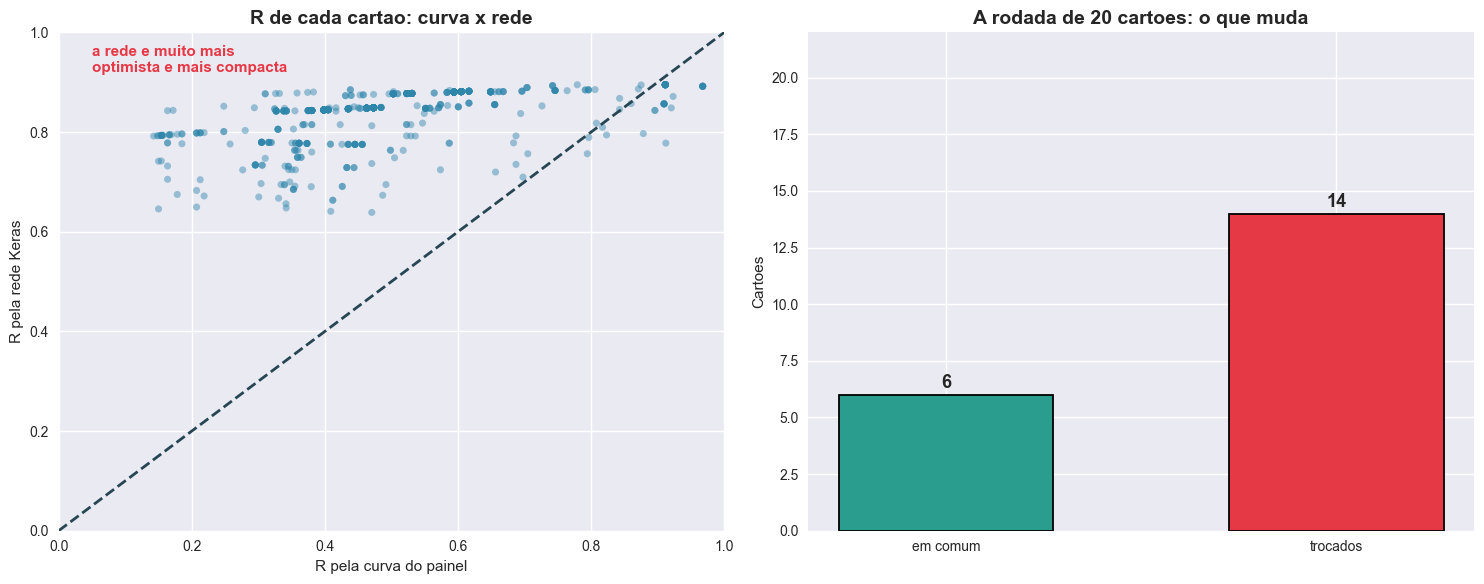

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(cart['R_curva'], cart['R_rede'], s=26, alpha=0.45,
            color='#2E86AB', edgecolor='none')
ax1.plot([0, 1], [0, 1], '--', color='#264653', linewidth=2)
ax1.set_title('R de cada cartao: curva x rede', fontsize=14, fontweight='bold')
ax1.set_xlabel('R pela curva do painel')
ax1.set_ylabel('R pela rede Keras')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.text(0.05, 0.92, 'a rede e muito mais\noptimista e mais compacta',
         fontsize=11, fontweight='bold', color='#E63946')

ax2.bar(['em comum', 'trocados'], [comuns, 20 - comuns],
        color=['#2A9D8F', '#E63946'], edgecolor='black', linewidth=1.3, width=0.55)
for i, v in enumerate([comuns, 20 - comuns]):
    ax2.text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=13)
ax2.set_title('A rodada de 20 cartoes: o que muda', fontsize=14, fontweight='bold')
ax2.set_ylabel('Cartoes')
ax2.set_ylim(0, 22)

plt.tight_layout()
plt.show()

### Resposta 7

**A fila muda muito mais do que a correlação sugeria.**

Os dois modelos concordam na matéria da rodada, e a correlação de ordem entre os dois `R` é 0,76 —
alta. Mesmo assim, **a rodada de hoje à noite só tem 6 dos 20 cartões em comum**. Catorze cartões
trocam.

Não é contradição: correlação alta no conjunto todo convive com desacordo grande na ponta, e é
exatamente a ponta que vira rodada. Vinte cartões em 628 são os 3% do topo — a região onde os dois
modelos menos se parecem.

E aqui está o resultado que importa para a sua reflexão: **eu não tenho como saber se esses catorze
cartões novos são melhores.** A AUC de 0,60 foi medida em revisões de idioma no Duolingo, com
intervalos de horas e dias. Os meus cartões são de Legislação de Trânsito, com intervalos de
semanas, e a rede é sistematicamente otimista com eles — `R` médio de 0,83 contra 0,50 da curva.
É transferência de domínio sem validação no domínio de destino.

> **Trocar agora seria cometer o erro que a reflexão descreve, só que na direção oposta:** em vez de
> entregar um modelo bom que ninguém usa, eu colocaria em produção um modelo melhor no papel, cuja
> melhora nunca foi medida onde ela precisa valer.

# 8. O que vai para o painel, e o que não vai

**Não vai:** a rede substituindo a curva. Falta a única evidência que decide — desempenho medido
nos meus próprios cartões, não nos do Duolingo.

**Vai, e é o resultado prático desta entrega:** o painel passa a **gravar a previsão antes da
resposta**. Hoje ele calcula `R`, monta a rodada e joga o `R` fora. Se ele guardar, cada revisão
minha vira uma linha de um dataset igual ao do Duolingo — `p_recall`, `delta`, `history_seen`,
`history_correct` — e em algumas semanas a comparação deixa de depender de dado emprestado.

São três campos a mais por resposta. Com as 1.599 respostas que eu já dei, o volume de um mês já
daria para refazer esta comparação com dado próprio.

**É a mesma lição da 1ª entrega, do outro lado.** Lá, um alerta de revisão que não virava ação. Aqui,
uma previsão que não vira medida. Nos dois casos o ciclo fica aberto, e ciclo aberto não melhora.

# 9. Conclusão

**1. A métrica óbvia premiou o modelo inútil.** No MAE, "responda sempre que vai lembrar" venceu
tudo — inclusive a rede treinada. Um modelo que nunca aponta um cartão seria o melhor do placar.
Sem linha de base, esse número teria passado.

**2. A métrica certa saiu do produto, não da estatística.** O painel não precisa saber se eu lembro;
precisa ordenar cartões. Trocando MAE por AUC, o placar inverte: rede 0,600, curva do painel 0,548.

**3. A curva que eu uso hoje está perto de uma moeda.** AUC 0,548. Foi escrita por leitura, sem
nenhuma constante ajustada, e esta entrega é a primeira vez que ela foi medida contra alguma coisa.
Saber disso já vale a tarefa.

**4. A rede é melhor e mesmo assim não entra em produção.** Ela troca **14 dos 20 cartões** da
rodada, e não existe evidência de que esses catorze sejam melhores — a AUC foi medida em revisões de
idioma, não nas minhas de Legislação de Trânsito. Entregar sem medir seria trocar um chute por outro
mais caro.

**5. O que entra é o instrumento de medida**, não o modelo: gravar a previsão antes da resposta,
para que em um mês a decisão seja tomada com dado meu.

---

## Respondendo à reflexão de 10/09

> *"Produtos de dados e IA não são entregues quando um modelo é treinado ou um dashboard é publicado.
> São entregues quando alguém toma uma decisão melhor por causa da solução construída."*

Pelo critério da frase, **esta tarefa não entregou um produto** — entregou duas coisas menores e
honestas: a medida de que a curva atual está quase no acaso, e o registro que vai permitir decidir
isso com dado próprio.

O modelo está treinado, calibrado e é melhor no papel. Ele continua sendo modelo. Vira produto no
dia em que eu revisar um cartão diferente por causa dele **e isso tiver sido medido**.

In [19]:
print("=" * 68)
print("  RESUMO EXECUTIVO")
print("=" * 68)
print()
print(f"  Dataset ............... Duolingo / Settles & Meeder (ACL 2016)")
print(f"  Revisoes usadas ....... {len(df):,} de 12,9 milhoes")
print(f"  Pessoas ............... {df['user_id'].nunique():,}  (divisao treino/teste por pessoa)")
print(f"  Rede .................. {modelo.count_params():,} parametros, "
      f"{len(historico.history['loss'])} epocas")
print()
print("  PLACAR (conjunto de teste)")
print(f"    {'modelo':<26}{'MAE':>8}{'RMSE':>8}{'AUC':>8}")
for linha in placar:
    auc = f"{linha['AUC']:.3f}" if linha['AUC'] == linha['AUC'] else "  -  "
    print(f"    {linha['modelo']:<26}{linha['MAE']:>8.4f}{linha['RMSE']:>8.4f}{auc:>8}")
print()
print("  O ACHADO")
print("    O melhor MAE e de um modelo que nunca aponta cartao nenhum.")
print("    Trocando MAE por AUC, a rede passa a curva do painel.")
print()
print("  O TESTE DE PRODUTO (628 cartoes reais)")
print(f"    Rodada de 20 cartoes: {comuns} iguais, {20-comuns} trocados")
print(f"    Correlacao de ordem entre os dois R: "
      f"{cart['R_curva'].corr(cart['R_rede'], method='spearman'):.3f}")
print("    Decisao: NAO trocar ainda -- AUC medida em outro dominio.")
print("    Entra no painel: gravar a previsao antes da resposta.")
print()
print("=" * 68)

  RESUMO EXECUTIVO

  Dataset ............... Duolingo / Settles & Meeder (ACL 2016)
  Revisoes usadas ....... 550,000 de 12,9 milhoes
  Pessoas ............... 12,266  (divisao treino/teste por pessoa)
  Rede .................. 2,497 parametros, 8 epocas

  PLACAR (conjunto de teste)
    modelo                         MAE    RMSE     AUC
    B0 sempre 1,0 (otimista)    0.0987  0.2827     -  
    B1 constante = media        0.1726  0.2651     -  
    B2 curva do painel          0.1183  0.2840   0.548
    MLP Keras                   0.1659  0.2632   0.600

  O ACHADO
    O melhor MAE e de um modelo que nunca aponta cartao nenhum.
    Trocando MAE por AUC, a rede passa a curva do painel.

  O TESTE DE PRODUTO (628 cartoes reais)
    Rodada de 20 cartoes: 6 iguais, 14 trocados
    Correlacao de ordem entre os dois R: 0.752
    Decisao: NAO trocar ainda -- AUC medida em outro dominio.
    Entra no painel: gravar a previsao antes da resposta.

